In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.applications import Xception
from tensorflow.keras.optimizers import Adam
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import cv2

In [4]:
image_size = 299
data_dir = "dataset/"
labels = ["glioma_tumor", "no_tumor", "meningioma_tumor", "pituitary_tumor"]

In [5]:
def load_images(directory, image_size):
    X = []
    y = []

    for label in labels:
        folderPath = os.path.join(directory, label)
        for filename in os.listdir(folderPath):
            img = cv2.imread(os.path.join(folderPath, filename))
            img = cv2.resize(img, (image_size, image_size))
            X.append(img)
            y.append(label)

    return np.array(X), np.array(y)

In [6]:
X, y = load_images(os.path.join(data_dir, "Training"), image_size)
X_test, y_test = load_images(os.path.join(data_dir, "Testing"), image_size)

In [7]:
X = np.concatenate((X, X_test), axis=0)
y = np.concatenate((y, y_test), axis=0)

In [8]:
X, y = shuffle(X, y, random_state=42)

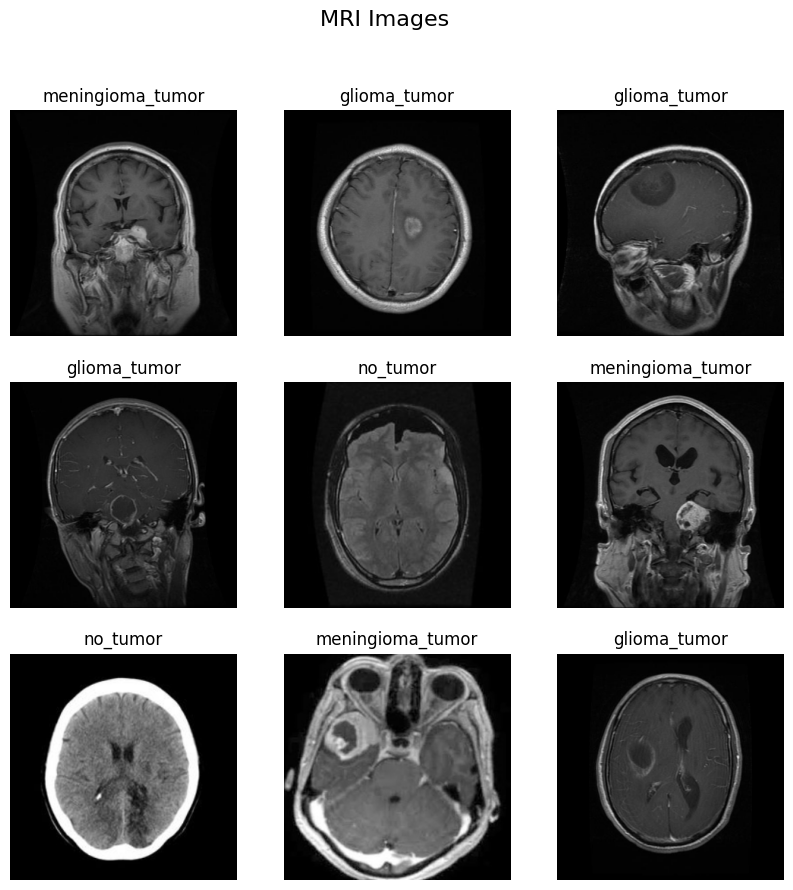

In [9]:
def visualize_images(images, labels, title):
    plt.figure(figsize=(10, 10))
    plt.suptitle(title, fontsize=16)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(labels[i])
        plt.axis('off')

    plt.show()

visualize_images(X, y, 'MRI Images')

In [10]:
y = tf.keras.utils.to_categorical([labels.index(label) for label in y])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [12]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [13]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_datagen.fit(X_train)

In [14]:
xception_model = Xception(weights='imagenet', include_top=False, input_shape=(image_size, image_size, 3))

for layer in xception_model.layers:
    layer.trainable = False

In [15]:
model = keras.Sequential([
    xception_model,
    Flatten(),
    Dense(512, activation="relu"),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(4, activation="softmax")
])

In [16]:
model.compile(optimizer=Adam(),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [17]:
history = model.fit(train_datagen.flow(X_train, y_train, batch_size=32),
                    steps_per_epoch=len(X_train) // 32,
                    epochs=50,
                    validation_data=(X_test, y_test))

KeyboardInterrupt: 

NameError: name 'history' is not defined

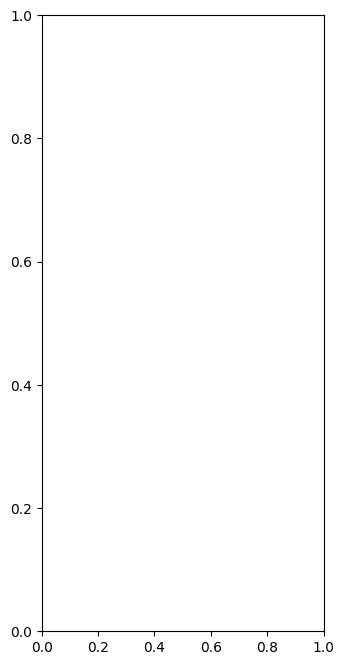

In [18]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [19]:
model.evaluate(X_test,y_test)

11/11 [==============================] - 25s 2s/step - loss: 1.4268 - accuracy: 0.3058


[1.4267988204956055, 0.3058103919029236]

11/11 [==============================] - 55s 5s/step


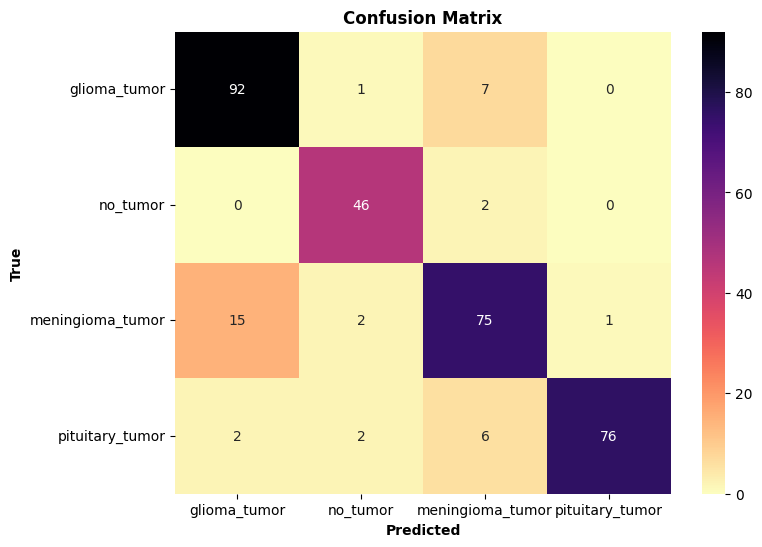

In [24]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='magma_r', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted', fontweight='bold')
plt.ylabel('True', fontweight='bold')
plt.title('Confusion Matrix', fontweight='bold')
plt.show()

In [25]:
def preprocess_image(image_path, image_size):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (image_size, image_size))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    return img

def predict_tumor_class(model, image_path, labels):
    image = preprocess_image(image_path, image_size)
    prediction = model.predict(image)
    predicted_class = labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100
    return predicted_class, confidence

In [1]:
image_path = "dataset/Testing/no_tumor/image(103).jpg"
predicted_class, confidence = predict_tumor_class(model, image_path, labels)

print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}%")

NameError: name 'predict_tumor_class' is not defined

In [ ]:
from keras.models import load_model

model.save('model.h5')

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [1]:
import pandas as pd

# Convert the history dictionary to a Pandas DataFrame
history_df = pd.DataFrame(history.history)

# Save it to a CSV file
history_df.to_csv('model_training_data.csv', index=False)
print("Training data saved successfully!")

NameError: name 'history' is not defined